In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [ ]:
#1. Data/Domain Understanding and Exploration


In [ ]:
cardata = pd.read_csv('/content/adverts (2).csv')

<ipython-input-3-948eb21d632a>:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  cardata = pd.read_csv('/content/adverts (2).csv')


In [ ]:
cardata.shape

(297822, 12)

In [ ]:
cardata.columns

Index(['public_reference', 'mileage', 'reg_code', 'standard_colour',
       'standard_make', 'standard_model', 'vehicle_condition',
       'year_of_registration', 'price', 'body_type', 'crossover_car_and_van',
       'fuel_type'],
      dtype='object')

In [ ]:
cardata.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970.0,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000.0,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000.0,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995.0,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995.0,SUV,False,Diesel


In [ ]:
cardata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297822 entries, 0 to 297821
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       297822 non-null  int64  
 1   mileage                297733 non-null  float64
 2   reg_code               274354 non-null  object 
 3   standard_colour        293858 non-null  object 
 4   standard_make          297822 non-null  object 
 5   standard_model         297822 non-null  object 
 6   vehicle_condition      297821 non-null  object 
 7   year_of_registration   273247 non-null  float64
 8   price                  297821 non-null  float64
 9   body_type              297216 non-null  object 
 10  crossover_car_and_van  297821 non-null  object 
 11  fuel_type              297355 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 27.3+ MB


In [ ]:
cardata.describe()

,public_reference,mileage,year_of_registration,price
count,2.978220e+05,297733.000000,273247.000000,2.978210e+05
mean,2.020071e+14,37762.247433,2015.006555,1.729568e+04
std,1.678783e+10,34882.905582,8.004086,4.115876e+04
min,2.013092e+14,0.000000,999.000000,1.800000e+02
25%,2.020090e+14,10500.000000,2013.000000,7.495000e+03
50%,2.020093e+14,28612.000000,2016.000000,1.260000e+04
75%,2.020102e+14,56936.000000,2018.000000,2.000000e+04
max,2.020110e+14,999999.000000,2020.000000,9.999999e+06


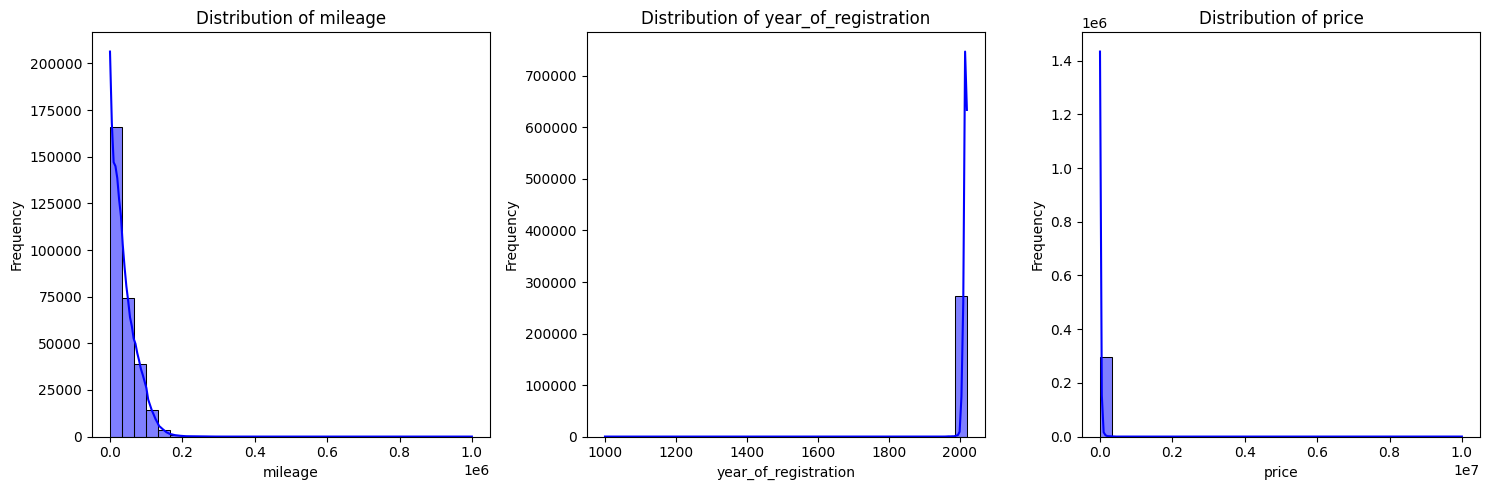

(public_reference           int64
 mileage                  float64
 reg_code                  object
 standard_colour           object
 standard_make             object
 standard_model            object
 vehicle_condition         object
 year_of_registration     float64
 price                    float64
 body_type                 object
 crossover_car_and_van     object
 fuel_type                 object
 dtype: object,
 {'reg_code': array([nan, '61', '17', '16', '64'], dtype=object),
  'standard_colour': array(['Grey', 'Blue', 'Brown', 'Red', 'Bronze'], dtype=object),
  'standard_make': array(['Volvo', 'Jaguar', 'SKODA', 'Vauxhall', 'Land Rover'], dtype=object),
  'standard_model': array(['XC90', 'XF', 'Yeti', 'Mokka', 'Range Rover Sport'], dtype=object),
  'vehicle_condition': array(['NEW', 'USED', nan], dtype=object),
  'body_type': array(['SUV', 'Saloon', 'Hatchback', 'Convertible', 'Limousine'],
        dtype=object),
  'fuel_type': array(['Petrol Plug-in Hybrid', 'Diesel', 'Petro

In [ ]:
#1.1 Meaning and Type of Features; Analysis of Distributions
# Display feature types
feature_types = cardata.dtypes


numerical_features = ['mileage', 'year_of_registration', 'price']
categorical_features = ['reg_code', 'standard_colour', 'standard_make',
                        'standard_model', 'vehicle_condition', 'body_type',
                        'fuel_type']


plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    sns.histplot(cardata[feature], bins=30, kde=True, color='blue')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

categorical_info = {feature: cardata[feature].unique()[:5] for feature in categorical_features}
feature_types, categorical_info


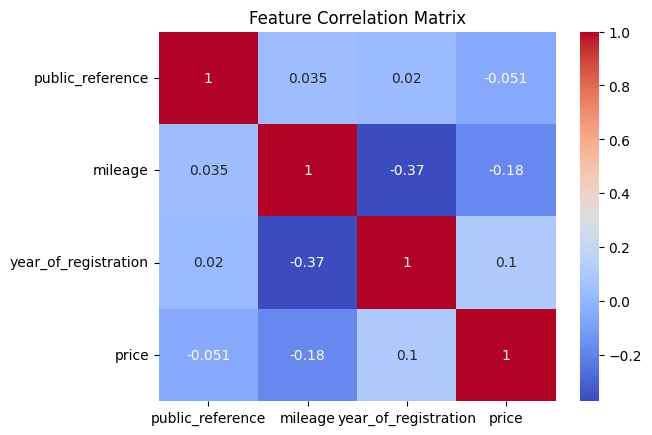

In [ ]:
#1.2  Analysis of Predictive Power of Features
# Select only numerical columns for correlation calculation
numerical_columns = cardata.select_dtypes(include=np.number).columns
correlation_matrix = cardata[numerical_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

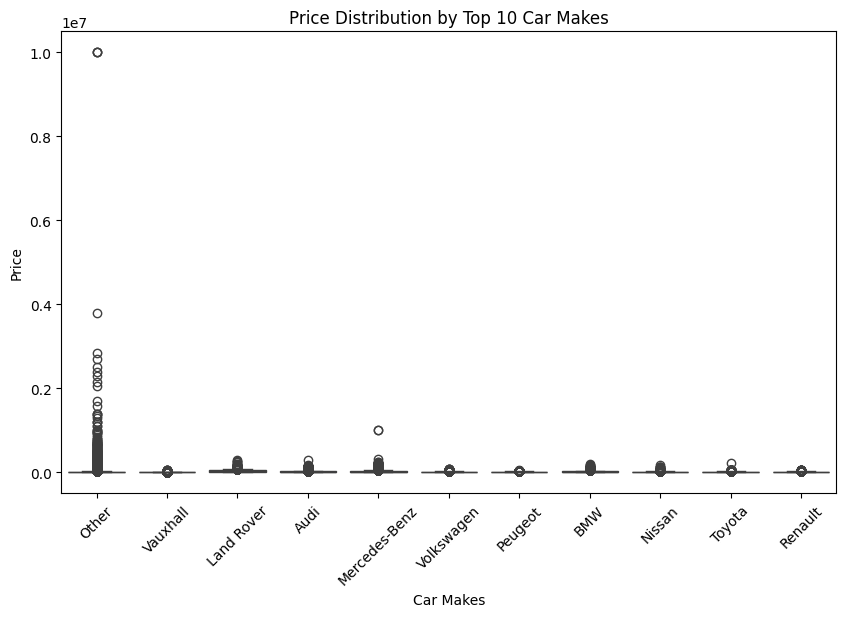

,mileage,year_of_registration,price
count,297733.000000,273247.000000,2.978210e+05
mean,37762.247433,2015.006555,1.729568e+04
std,34882.905582,8.004086,4.115876e+04
min,0.000000,999.000000,1.800000e+02
25%,10500.000000,2013.000000,7.495000e+03
50%,28612.000000,2016.000000,1.260000e+04
75%,56936.000000,2018.000000,2.000000e+04
max,999999.000000,2020.000000,9.999999e+06


In [ ]:
#1.3 Data Processing for Data Exploration and Visualization
numerical_summary = cardata[numerical_features].describe()

top_categories = cardata['standard_make'].value_counts().index[:10]
cardata['top_makes'] = cardata['standard_make'].apply(
    lambda x: x if x in top_categories else 'Other')

plt.figure(figsize=(10, 6))
sns.boxplot(x='top_makes', y='price', data=cardata)
plt.title("Price Distribution by Top 10 Car Makes")
plt.xticks(rotation=45)
plt.xlabel("Car Makes")
plt.ylabel("Price")
plt.show()

numerical_summary


In [ ]:
#2. Data Processing for Machine learning
cardata.isnull().sum()

,0
public_reference,0
mileage,89
reg_code,23468
standard_colour,3964
standard_make,0
standard_model,0
vehicle_condition,1
year_of_registration,24575
price,1
body_type,606


In [ ]:
cardata.duplicated().sum()

0

<ipython-input-14-7c36c2dbbc8e>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")


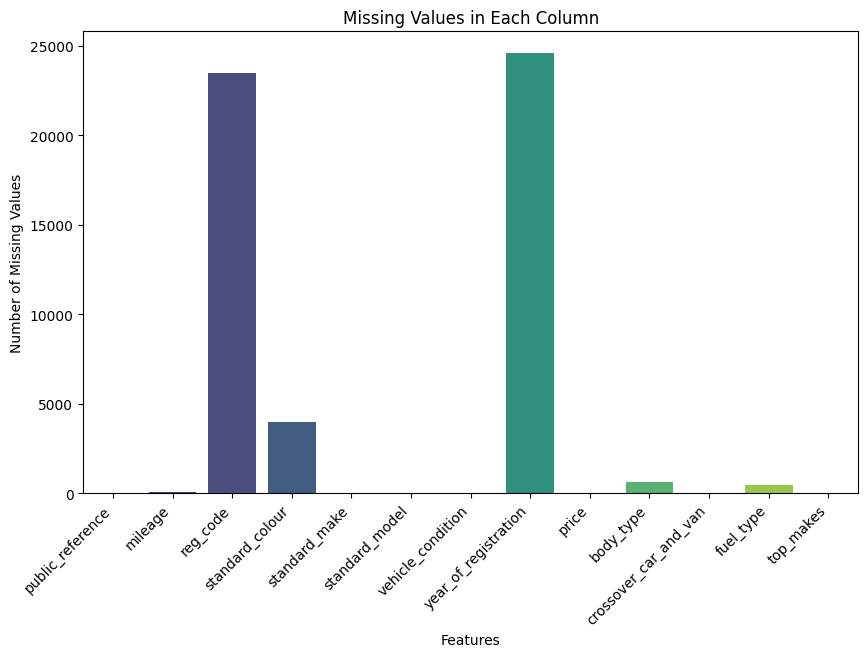

In [ ]:
# Plot for missing values for better visualization
missing_values = cardata.isnull().sum()
plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Missing Values in Each Column")
plt.ylabel("Number of Missing Values")
plt.xlabel("Features")
plt.show()

In [ ]:
numerical_features = cardata.select_dtypes(include=['number']).columns


for column in numerical_features:
    cardata[column].fillna(cardata[column].median(), inplace=True)

<ipython-input-15-006e8c14dd13>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cardata[column].fillna(cardata[column].median(), inplace=True)


In [ ]:
categorical_features = cardata.select_dtypes(include=['object', 'bool']).columns.tolist()
for column in categorical_features:
    cardata[column].fillna(cardata[column].mode()[0], inplace=True)

<ipython-input-16-2bca985e15cd>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cardata[column].fillna(cardata[column].mode()[0], inplace=True)
<ipython-input-16-2bca985e15cd>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cardata[column].fillna(cardata[column].mode()[0], inplace=True)


In [ ]:
print("Missing Values Per Column:")
print(cardata.isnull().sum())

Missing Values Per Column:
public_reference         0
mileage                  0
reg_code                 0
standard_colour          0
standard_make            0
standard_model           0
vehicle_condition        0
year_of_registration     0
price                    0
body_type                0
crossover_car_and_van    0
fuel_type                0
top_makes                0
dtype: int64


In [ ]:
#Removing Outliers
def remove_outliers(df, column):
    if df is None or df.empty:
        print(f"Warning: DataFrame is empty for column: {column}. Returning original DataFrame.")
        return df

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    if filtered_df.empty:
        print(f"Warning: Filtering for outliers in column '{column}' resulted in an empty DataFrame. Returning original DataFrame.")
        return df

    return filtered_df

In [ ]:
cardata_copy = cardata.copy()
for column in ['price', 'mileage']:
    cardata_copy = remove_outliers(cardata_copy, column)

In [ ]:
cardata_copy.shape

(272947, 13)

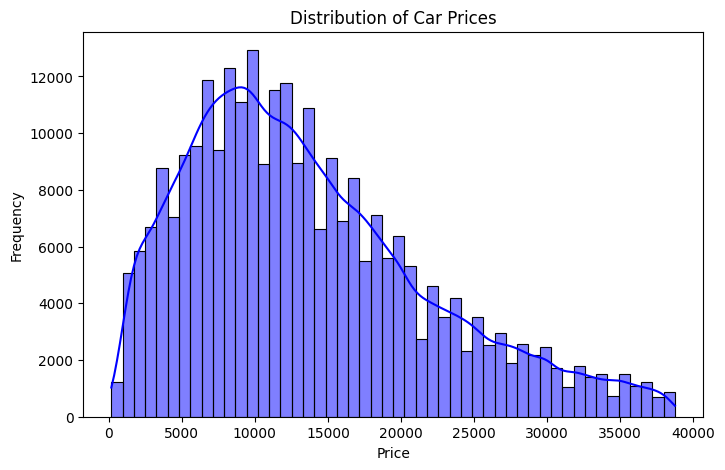

In [ ]:
# Visualize price distribution
plt.figure(figsize=(8, 5))
sns.histplot(cardata_copy['price'], bins=50, kde=True, color='blue')
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

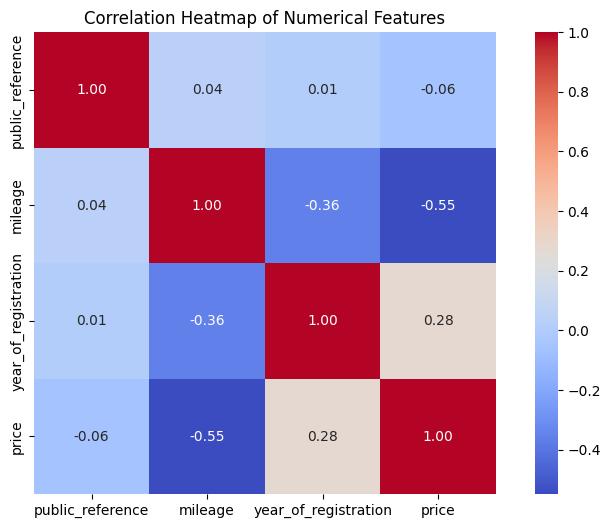

In [ ]:
numerical_data = cardata_copy.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numerical_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

<ipython-input-23-e759e04a7b3b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cardata, x='vehicle_condition', y='price', palette='Set2')


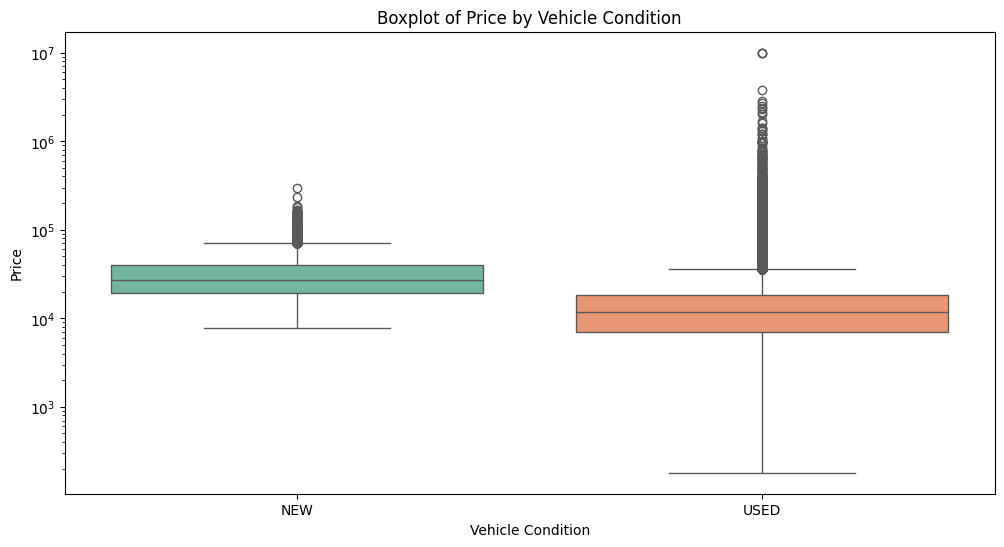

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=cardata, x='vehicle_condition', y='price', palette='Set2')
plt.title("Boxplot of Price by Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Price")
plt.yscale('log')
plt.show()

<ipython-input-24-5302e7f49dae>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cardata, x='vehicle_condition', palette='Set3')


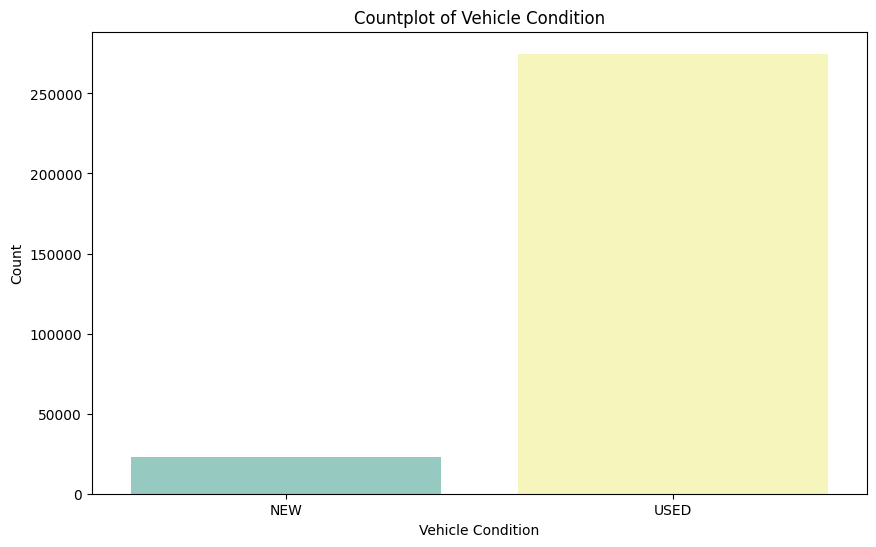

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=cardata, x='vehicle_condition', palette='Set3')
plt.title("Countplot of Vehicle Condition")
plt.xlabel("Vehicle Condition")
plt.ylabel("Count")
plt.show()

In [ ]:
#2.2. Feature Engineering, Data Transformations, Feature Selection
current_year = 2025
cardata_copy['vehicle_age'] = current_year - cardata_copy['year_of_registration']


In [ ]:
if 'price' in cardata.columns and 'mileage' in cardata.columns:
    cardata['PricePerMile'] = cardata['price'] / cardata['mileage']
    print("Added Feature: PricePerMile")

Added Feature: PricePerMile


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cardata_copy[['mileage', 'vehicle_age']] = scaler.fit_transform(cardata_copy[['mileage', 'vehicle_age']])

cardata_copy['price'] = scaler.fit_transform(cardata_copy[['price']])
cardata_copy.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,top_makes,vehicle_age
1,202007020778260,2.278638,61,Blue,Jaguar,XF,USED,2011.0,-0.801580,Saloon,False,Diesel,Other,0.545381
2,202007020778474,-0.954112,17,Grey,SKODA,Yeti,USED,2017.0,0.041247,SUV,False,Petrol,Other,-0.247601
3,202007080986776,0.243322,16,Brown,Vauxhall,Mokka,USED,2016.0,-0.681778,Hatchback,False,Diesel,Vauxhall,-0.115438
4,202007161321269,0.854914,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,1.605896,SUV,False,Diesel,Land Rover,0.016726
5,202009304412074,-0.690162,17,Blue,Audi,S5,USED,2017.0,1.847306,Convertible,False,Petrol,Audi,-0.247601


In [ ]:
scaler = StandardScaler()
cardata_copy[['mileage', 'vehicle_age']] = scaler.fit_transform(cardata_copy[['mileage', 'vehicle_age']])


cardata_copy['price'] = scaler.fit_transform(cardata_copy[['price']])
cardata_copy.head()


,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type,top_makes,vehicle_age
1,202007020778260,2.278638,61,Blue,Jaguar,XF,USED,2011.0,-0.801580,Saloon,False,Diesel,Other,0.545381
2,202007020778474,-0.954112,17,Grey,SKODA,Yeti,USED,2017.0,0.041247,SUV,False,Petrol,Other,-0.247601
3,202007080986776,0.243322,16,Brown,Vauxhall,Mokka,USED,2016.0,-0.681778,Hatchback,False,Diesel,Vauxhall,-0.115438
4,202007161321269,0.854914,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,1.605896,SUV,False,Diesel,Land Rover,0.016726
5,202009304412074,-0.690162,17,Blue,Audi,S5,USED,2017.0,1.847306,Convertible,False,Petrol,Audi,-0.247601


In [ ]:
cardata_copy = cardata_copy.drop(columns=['public_reference', 'reg_code','year_of_registration'])

In [ ]:
cardata_copy.head()

,mileage,standard_colour,standard_make,standard_model,vehicle_condition,price,body_type,crossover_car_and_van,fuel_type,top_makes,vehicle_age
1,2.278638,Blue,Jaguar,XF,USED,-0.801580,Saloon,False,Diesel,Other,0.545381
2,-0.954112,Grey,SKODA,Yeti,USED,0.041247,SUV,False,Petrol,Other,-0.247601
3,0.243322,Brown,Vauxhall,Mokka,USED,-0.681778,Hatchback,False,Diesel,Vauxhall,-0.115438
4,0.854914,Grey,Land Rover,Range Rover Sport,USED,1.605896,SUV,False,Diesel,Land Rover,0.016726
5,-0.690162,Blue,Audi,S5,USED,1.847306,Convertible,False,Petrol,Audi,-0.247601


In [ ]:
categorical_columns = cardata_copy.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Columns: {categorical_columns}")

In [ ]:

low_frequency = [col for col in categorical_columns if cardata_copy[col].nunique() <= 10]
high_frequency = [col for col in categorical_columns if cardata_copy[col].nunique() > 10]

print(f"Low Frequency Columns: {low_frequency}")
print(f"High Frequency Columns: {high_frequency}")

In [ ]:
# Apply one-hot encoding for low-frequency categorical columns
if low_frequency:
    cardata_copy = pd.get_dummies(cardata_copy, columns=low_frequency, drop_first=True)

    # Convert one-hot encoded columns to integers
    for col in cardata_copy.columns:
        if any(col.startswith(f"{low}_") for low in low_frequency):
            cardata_copy[col] = cardata_copy[col].astype(int)

# Apply frequency encoding for high-frequency categorical columns
for col in high_frequency:
    freq_map = cardata_copy[col].value_counts(normalize=True).to_dict()
    cardata_copy[col] = cardata_copy[col].map(freq_map)


#ensure crossover_car_and_van is binary
cardata_copy['crossover_car_and_van'] = cardata_copy['crossover_car_and_van'].astype(int)


Categorical Columns: ['standard_colour', 'standard_make', 'standard_model', 'vehicle_condition', 'body_type', 'fuel_type', 'top_makes']
Low Frequency Columns: ['vehicle_condition', 'fuel_type']
High Frequency Columns: ['standard_colour', 'standard_make', 'standard_model', 'body_type', 'top_makes']


In [ ]:
# 3 Model Building
# 3.1. Algorithm Selection, Model Instantiation and Configuration (3)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "k-Nearest Neighbors": KNeighborsRegressor()
}
models

{'Linear Regression': LinearRegression(),
 'Decision Tree': DecisionTreeRegressor(random_state=42),
 'k-Nearest Neighbors': KNeighborsRegressor()}

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Define your models within a dictionary called 'models'
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "K-Nearest Neighbors": KNeighborsRegressor()
}

cardata_copy['price'] = cardata_copy['price'].fillna(cardata_copy['price'].median())

X = cardata_copy.drop('price', axis=1)
y = cardata_copy['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['R2'], ascending=False)

print("Model Ranking based on R2 Score:")
print(results_df)

Model Ranking based on R2 Score:
                 Model       MSE      RMSE        R2
1        Decision Tree  0.120243  0.346761  0.880043
2  K-Nearest Neighbors  0.156744  0.395909  0.843629
0    Linear Regression  0.489715  0.699796  0.511449


In [ ]:
#4 model Evaluation and analysis

In [ ]:
#4.1 Coarse-Grained Evaluation/Analysis


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_val_preds = lr_model.predict(X_val)
lr_val_rmse = np.sqrt(mean_squared_error(y_val, lr_val_preds))
print(f"Linear Regression Validation RMSE: {lr_val_rmse}")

In [ ]:
# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_val_preds = dt_model.predict(X_val)
dt_val_rmse = np.sqrt(mean_squared_error(y_val, dt_val_preds))
print(f"Decision Tree Validation RMSE: {dt_val_rmse}")


In [ ]:
# K-Nearest Neighbors
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)
knn_val_preds = knn_model.predict(X_val)
knn_val_rmse = np.sqrt(mean_squared_error(y_val, knn_val_preds))
print(f"K-Nearest Neighbors Validation RMSE: {knn_val_rmse}")


In [ ]:

validation_results = {
    "Linear Regression": lr_val_rmse,
    "Decision Tree": dt_val_rmse,
    "K-Nearest Neighbors": knn_val_rmse
}
best_model = min(validation_results, key=validation_results.get)
print(f"\nBest model based on Validation RMSE: {best_model} with RMSE {validation_results[best_model]}")

In [ ]:
def evaluate_regression_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}\n")
    return r2, mse, mae

In [ ]:
# Evaluate KNN Regressor
y_pred_knn = knn_model.predict(X_val)
evaluate_regression_model(y_val, y_pred_knn, "KNN Regressor")

In [ ]:
#"Decision Tree Regressor"
y_pred_dt = dt_model.predict(X_val)
evaluate_regression_model(y_val, y_pred_dt, "Decision Tree Regressor")

In [ ]:
# Calculate Actual vs Predicted for each model
y_pred_knn = knn_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)



In [ ]:
# Plot Actual vs Predicted for each model
plt.figure(figsize=(8, 6))

In [ ]:
# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')  # Diagonal line (changed to blue for contrast)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (K-Nearest Neighbors)")
plt.grid(True)
plt.show()

In [ ]:
# Plot actual vs predicted for best model (e.g., Decision Tree )
y_pred_dtr = dt_model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dtr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Decision Tree)")
plt.grid(True)
plt.show()

In [ ]:
# Create a scatter plot of actual vs. predicted values LInear regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Linear Regression)")
plt.grid(True)
plt.show()

In [ ]:
#4.2 Feature Importance

In [ ]:
feature_importances = dt_model.feature_importances_
sorted_idx = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.xticks(range(len(sorted_idx)), X_train.columns[sorted_idx], rotation=90)
plt.title("Feature Importance (Decision Tree Regressor)")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
#4.3. Fine-Grained Evaluation
residuals_knn = y_test - y_pred_knn

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_knn, y=residuals_knn, color='blue')
plt.title("Residuals vs Fitted Values (Decision Tree)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution (Decision Tree Regressor)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [ ]:
# Plot residuals vs. fitted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_dtr, y=residuals, color='red')
plt.title("Residuals vs Fitted Values (Decision Tree)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()